In [1]:
import math
import yfinance as yf
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler 
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Read downloaded data from Yahoo finance
stock_data = pd.read_csv('TSLA.csv')
            
stock_data.head()

2022-12-26 08:09:59.444732: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


,Date,Open,High,Low,Close,Adj Close,Volume
0,2012-01-19,1.812667,1.849333,1.774000,1.784000,1.784000,18694500
1,2012-01-20,1.793333,1.800000,1.760000,1.773333,1.773333,9934500
2,2012-01-23,1.787333,1.814000,1.773333,1.784667,1.784667,8919000
3,2012-01-24,1.775333,1.845333,1.762667,1.828000,1.828000,12870000
4,2012-01-25,1.818000,1.867333,1.803333,1.864667,1.864667,9168000


In [2]:
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2748 non-null   object 
 1   Open       2748 non-null   float64
 2   High       2748 non-null   float64
 3   Low        2748 non-null   float64
 4   Close      2748 non-null   float64
 5   Adj Close  2748 non-null   float64
 6   Volume     2748 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 150.4+ KB


In [3]:
# Convert date column to Date object
stock_data.Date = pd.to_datetime(stock_data.Date)
stock_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2748 entries, 0 to 2747
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2748 non-null   datetime64[ns]
 1   Open       2748 non-null   float64       
 2   High       2748 non-null   float64       
 3   Low        2748 non-null   float64       
 4   Close      2748 non-null   float64       
 5   Adj Close  2748 non-null   float64       
 6   Volume     2748 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 150.4 KB


None


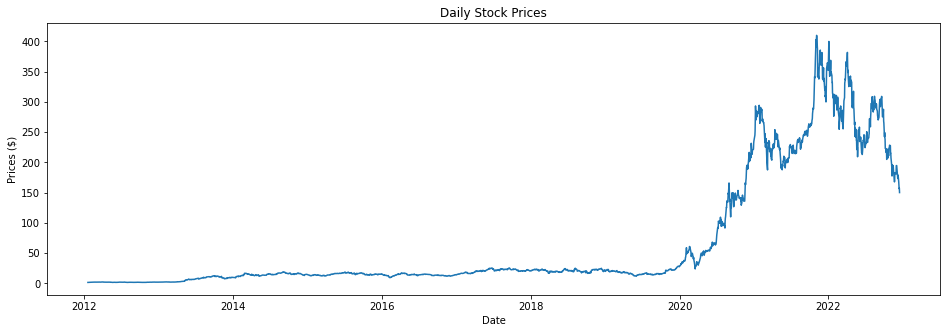

In [4]:
# Visualize. Print line chart
stock_data.index.freq = 'MS'
stock_data = stock_data.set_index("Date")
plt.figure(figsize=(16, 5))
plt.title('Daily Stock Prices')
plt.plot(stock_data['Close'])
plt.xlabel('Date')
plt.ylabel('Prices ($)')
print (stock_data.index.freq)

In [5]:
close_prices = stock_data['Close']
values = close_prices.values # Convert closing prices to number series
training_data_len = math.ceil(len(values)* 0.8)  #Specify training data size as 80% of total

scaler = MinMaxScaler(feature_range=(0,1)) # Normalize our data so that it ranges between 0 and 1
scaled_data = scaler.fit_transform(values.reshape(-1,1)) # Convert ot a 2d array
train_data = scaled_data[0: training_data_len, :] # training dataset

x_train = [] # feature data
y_train = [] # label data

# 60 days window
#Create a 60-days window of historical prices (i-60) as our feature data (x_train) and the following 60-days window as label data (y_train)
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    
x_train, y_train = np.array(x_train), np.array(y_train) # Convert to numpy array

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1)) # Convert to 3d as per Tensorflow requirement

In [6]:
test_data = scaled_data[training_data_len-60: , : ] # The last 20
x_test = []
y_test = values[training_data_len:]

# 60 days window
for i in range(60, len(test_data)):
  x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test) # Convert to numpy array
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1)) # Reshape to 3d as per TensorFlow requirement

In [7]:
model = keras.Sequential() # A model linear stack of layers

#100 network units. Set the return_sequence to true so that the output of the layer will be another sequence of the same length.
model.add(layers.LSTM(100, return_sequences=True, input_shape=(x_train.shape[1], 1)))

# set the return_sequence to false for this time to only return the last output in the output sequence.
model.add(layers.LSTM(100, return_sequences=False))
model.add(layers.Dense(25)) # densely connected neural network layer with 25 network units
model.add(layers.Dense(1)) # Output of 1
model.summary()

2022-12-26 08:10:04.182271: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 60, 100)           40800     
                                                                 
 lstm_1 (LSTM)               (None, 100)               80400     
                                                                 
 dense (Dense)               (None, 25)                2525      
                                                                 
 dense_1 (Dense)             (None, 1)                 26        
                                                                 
Total params: 123,751
Trainable params: 123,751
Non-trainable params: 0
_________________________________________________________________


In [8]:
model.compile(optimizer='adam', loss='mean_squared_error')  # Set optimizer and loss function
model.fit(x_train, y_train, batch_size= 1, epochs=3) #Training LSTM Model

Epoch 1/3
2139/2139 [==============================] - 34s 15ms/step - loss: 3.5389e-04
Epoch 2/3
2139/2139 [==============================] - 33s 15ms/step - loss: 1.2296e-04
Epoch 3/3
2139/2139 [==============================] - 33s 16ms/step - loss: 1.2998e-04


In [9]:
predictions = model.predict(x_test) # Predict using Test data
predictions = scaler.inverse_transform(predictions) # denormalize the predicted stock prices.

# RMSE formula to calculate the degree of discrepancy between the predicted prices and real prices
rmse = np.sqrt(np.mean(predictions - y_test)**2) 
rmse

18/18 [==============================] - 1s 14ms/step


7.413089436864966

/var/folders/kc/9rzkxpw14fvg74hm1plpxvch0000gn/T/ipykernel_32773/1015704042.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  validation['Predictions'] = predictions


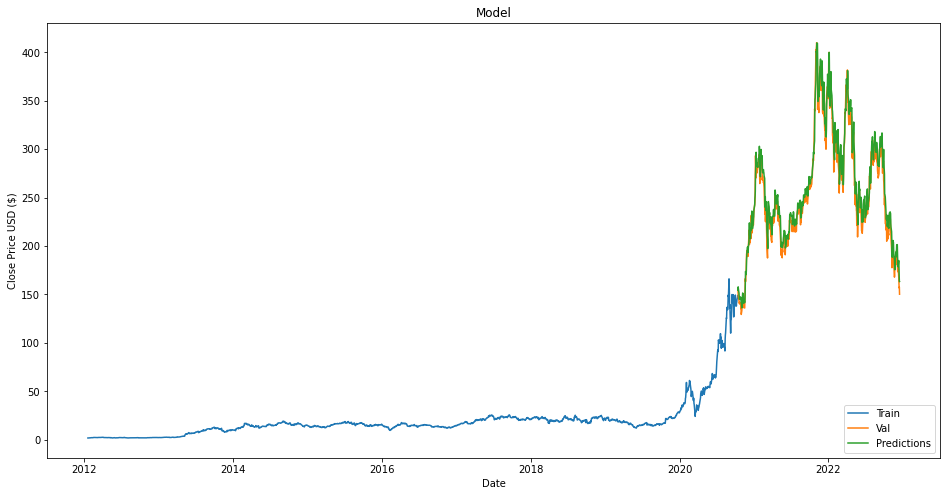

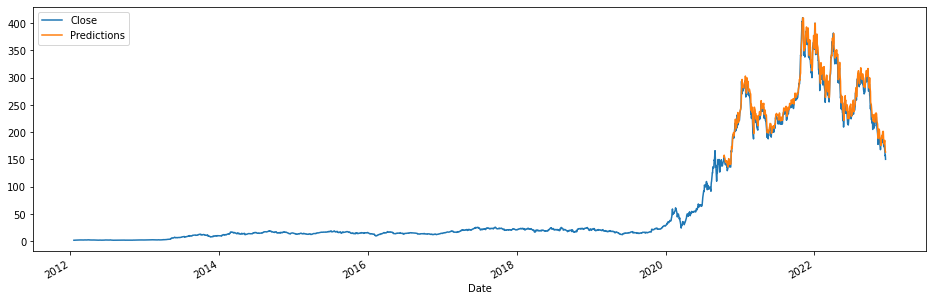

In [14]:

data = stock_data.filter(['Close'])
train = data[:training_data_len]
validation = data[training_data_len:]
validation['Predictions'] = predictions
plt.figure(figsize=(16,8))
plt.title('Model')
plt.xlabel('Date')
plt.ylabel('Close Price USD ($)')
plt.plot(train)
plt.plot(validation[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()


data.plot(figsize = (16,5), legend=True)
validation['Predictions'].plot(legend = True);

